In [1]:
# Cell No: 1
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import time
import matplotlib.pyplot as plt

In [2]:
# Cell No: 2
def load_data():
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()

    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)

    return x_train, y_train, x_test, y_test

In [3]:
# Cell No: 3
def conv_block(x, type_name):

    if type_name == "regular":
        x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)

    elif type_name == "dilated":
        x = layers.Conv2D(64, 3, dilation_rate=2, padding='same', activation='relu')(x)

    elif type_name == "depthwise":
        x = layers.SeparableConv2D(64, 3, padding='same', activation='relu')(x)

    elif type_name == "pointwise":
        x = layers.Conv2D(64, 1, padding='same', activation='relu')(x)

    elif type_name == "modified_dw":
        x = layers.DepthwiseConv2D(3, padding='same')(x)
        x = layers.Conv2D(64, 1, activation='relu')(x)

    else:
        raise ValueError("Unknown type")

    return x

In [4]:
# Cell No: 4
def build_model(kernel_type):
    inputs = layers.Input(shape=(32,32,3))

    x = conv_block(inputs, kernel_type)
    x = layers.MaxPooling2D()(x)

    x = conv_block(x, kernel_type)
    x = layers.MaxPooling2D()(x)

    x = conv_block(x, kernel_type)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    return Model(inputs, outputs)

In [5]:
# Cell No: 5
def train_model(model, x_train, y_train):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()

    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=64,
        verbose=1
    )

    end = time.time()

    return history, end - start

In [6]:
# Cell No: 6
def run_kernel_experiment():
    x_train, y_train, x_test, y_test = load_data()

    kernel_types = ["regular", "dilated", "depthwise", "pointwise", "modified_dw"]
    results = {}

    for k in kernel_types:
        print(f"\nRunning: {k}")

        model = build_model(k)
        history, t = train_model(model, x_train, y_train)

        loss, acc = model.evaluate(x_test, y_test, verbose=0)

        results[k] = {
            "history": history.history,
            "time": t,
            "acc": acc
        }

    return results

In [7]:
# Cell No: 7
def plot_kernel_results(results):
    plt.figure()

    for k, data in results.items():
        plt.plot(data["history"]["val_accuracy"], label=k)

    plt.title("Kernel Type Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 28s 0us/step

Running: regular
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 218ms/step - accuracy: 0.3179 - loss: 1.8130 - val_accuracy: 0.3961 - val_loss: 1.6191
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 134s 214ms/step - accuracy: 0.4381 - loss: 1.5425 - val_accuracy: 0.4596 - val_loss: 1.4638
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 129s 206ms/step - accuracy: 0.4929 - loss: 1.4004 - val_accuracy: 0.4944 - val_loss: 1.3801
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 206ms/step - accuracy: 0.5286 - loss: 1.3126 - val_accuracy: 0.5431 - val_loss: 1.2705
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 151s 221ms/step - accuracy: 0.5572 - loss: 1.2322 - val_accuracy: 0.5557 - val_loss: 1.2436
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 131s 210ms/step - accuracy: 0.5810 - loss: 1.1706 - val_accuracy: 0.5902 - val_loss: 1.1515
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 216ms/step - accuracy: 0.5987 - loss: 1.1281 - val_accuracy: 0.6117 - val_loss: 1.1039
Epoc

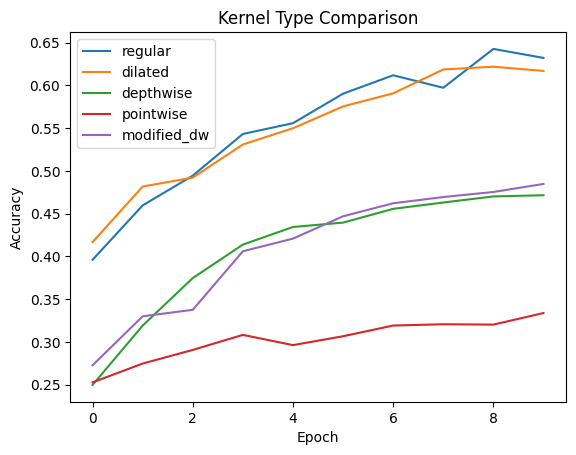

regular: Acc=0.6325, Time=1378.17s
dilated: Acc=0.6123, Time=1591.37s
depthwise: Acc=0.4775, Time=784.57s
pointwise: Acc=0.3369, Time=627.43s
modified_dw: Acc=0.4877, Time=787.70s


In [8]:
# Cell No: 8
def main():
    results = run_kernel_experiment()
    plot_kernel_results(results)

    for k, res in results.items():
        print(f"{k}: Acc={res['acc']:.4f}, Time={res['time']:.2f}s")

main()